# 06 — проверка движка nb05 и РЕАЛИСТИЧНЫЕ доходности

nb05 показал агрессивный режим **CAGR +817% / Sharpe 7.2 / maxDD −9.6%**. Цифры подозрительно большие
(и DD у агрессивного оказался *меньше*, чем у безопасного — что само по себе странно). Здесь:

1. **Проверяем движок на корректность** (сохраняется ли капитал, нет ли ошибки учёта).
2. **Разбираем, ОТКУДА 817%** — два in-sample артефакта: компаундинг-без-ёмкости и «защитные» пропуски.
3. **Прикладываем модель ёмкости+слиппеджа** (как nb02) → правдоподобный абсолют + стена масштабирования.
4. Вердикт: какое число честное.

Поток — тот же faithful combined, что в nb04/05 (pump 3%-стоп scale-in + WF-clf; dump price-step + 20%-стоп, no-KS).

In [1]:
import sys; sys.path.insert(0,'.')
from _lab import *
import numpy as np, pandas as pd, heapq
from sklearn.ensemble import HistGradientBoostingRegressor

# ---- faithful combined, идентично nb04/05 ----
d=np.load('../pump/_out/pump_features_3y.npz',allow_pickle=True)
X,y,ts,off=d['X'],d['y'],d['ts'],d['off']
o=np.argsort(ts); X,y,ts,off=X[o],y[o],ts[o],off[o]; N=len(y)
bounds=[0.40,0.55,0.70,0.85,1.00]; pred=np.full(N,np.nan)
for a,b in zip(bounds[:-1],bounds[1:]):
    i0,i1=int(N*a),int(N*b)
    mdl=HistGradientBoostingRegressor(max_depth=3,learning_rate=0.05,max_iter=300,
        l2_regularization=1.0,min_samples_leaf=50,random_state=0).fit(X[:i0],y[:i0])
    pred[i0:i1]=mdl.predict(X[i0:i1])
keepP=(pred>0)|np.isnan(pred)
entryP=pd.to_datetime(ts).tz_localize(None); exitP=entryP+pd.to_timedelta(off,'m')
pump=pd.DataFrame({'entry':entryP,'exit_ts':exitP,'pnl':y,'stream':'pump'})[keepP].reset_index(drop=True)
dump=pd.read_parquet('_out/dump_faithful.parquet')
dump['entry']=pd.to_datetime(dump.entry).dt.tz_localize(None)
dump['exit_ts']=pd.to_datetime(dump.exit_ts).dt.tz_localize(None)
both=pd.concat([pump,dump]).sort_values('entry').reset_index(drop=True)
span=(both.exit_ts.max()-both.entry.min()).days/365.25
print(f'faithful combined: {len(both)} сигналов (pump {len(pump)}, dump {len(dump)}), span {span:.2f}y')
print(f'per-trade edge (raw, idealized): {both.pnl.mean()*100:+.2f}% avg, win {(both.pnl>0).mean()*100:.0f}%')

faithful combined: 10096 сигналов (pump 6256, dump 3840), span 2.33y
per-trade edge (raw, idealized): +2.69% avg, win 62%


## 1. Движок корректен арифметически — но мерит «весь счёт», а он почти весь в кэше

Прогон nb05 (`run`) — это учёт `cash + deployed`. Проверим, что капитал **сохраняется** (открытие позиции
не создаёт и не уничтожает деньги: cash↓ ровно на notional, deployed↑ на столько же; при закрытии возвращается
notional·(1+pnl)). И сразу посмотрим **сколько капитала реально в рынке** — это ключ к «странному» Sharpe.

In [2]:
START=1000.
def run(df,pct,reserve,trace=False):
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    pnl=df.pnl.values
    cash=START;dep=0.;openh=[];eq_t=[];eq_v=[];dep_series=[]
    realized=0.0; invariant_ok=True
    for i in range(len(pnl)):
        while openh and openh[0][0]<=en[i]:
            _,no,pn=heapq.heappop(openh); cash+=no*(1+pn); dep-=no; realized+=no*pn
            eq_t.append(pd.Timestamp(_)); eq_v.append(cash+dep)
        eq=cash+dep; no=pct*eq
        # инвариант: equity до открытия == equity сразу после (открытие не меняет equity)
        if dep+no<=(1-reserve)*eq and no>0:
            pre=cash+dep; cash-=no;dep+=no
            if abs((cash+dep)-pre)>1e-6: invariant_ok=False
            heapq.heappush(openh,(ex[i],no,pnl[i]))
        dep_series.append(dep/(cash+dep) if (cash+dep)>0 else 0.0)
    for _,no,pn in sorted(openh): cash+=no*(1+pn);dep-=no;realized+=no*pn;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
    eq=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index();eq=eq[~eq.index.duplicated(keep='last')].resample('1D').last().ffill()
    return eq,cash,realized,invariant_ok,np.array(dep_series)

eq,fin,realized,ok,deps=run(both,0.05,0.10)
print('--- проверка учёта (агрессивный 5%, резерв 10%) ---')
print(f'инвариант "открытие не меняет equity": {"OK" if ok else "СЛОМАН"}')
print(f'final cash            ${fin:,.2f}')
print(f'START + sum(realized) ${START+realized:,.2f}   (должно совпасть с final)')
print(f'расхождение           ${abs(fin-(START+realized)):.6f}')
print()
print('--- сколько капитала в рынке (доля equity, по событиям) ---')
print(f'медиана задействовано : {np.median(deps)*100:.1f}%')
print(f'среднее задействовано : {deps.mean()*100:.1f}%')
print(f'95-й перцентиль       : {np.quantile(deps,.95)*100:.1f}%')
print(f'доля времени >50% в рынке: {(deps>0.5).mean()*100:.1f}%')

--- проверка учёта (агрессивный 5%, резерв 10%) ---
инвариант "открытие не меняет equity": OK
final cash            $173,529.50
START + sum(realized) $173,529.50   (должно совпасть с final)
расхождение           $0.000000

--- сколько капитала в рынке (доля equity, по событиям) ---
медиана задействовано : 25.0%
среднее задействовано : 42.4%
95-й перцентиль       : 90.0%
доля времени >50% в рынке: 38.4%


**Вывод по корректности.** Движок честный: капитал сохраняется до копейки (final = START + Σ realized pnl),
открытие позиции не двигает equity. Ошибки учёта нет.

Заодно развеиваем одно подозрение: счёт **НЕ простаивает в кэше** — по событиям задействовано в среднем ~42%
(медиана 25%, 95-й перцентиль 90%), ~38% времени более половины счёта в рынке. То есть Sharpe — это
легитимный дневной Sharpe вложенного счёта, **а не** артефакт «90% денег лежит мёртвым грузом». Значит
гигантские цифры — не от простоя; источник в другом (разделы 2 и 3).

## 2. Откуда 817%: артефакт №1 — компаундинг экспоненциален по доле ставки

Средний трейд ~+1.6%, но при `notional = f·equity` каждый выигрыш увеличивает базу для следующего.
За ~7000 перекрывающихся сделок это даёт **экспоненту по f**: крошечное изменение доли ставки (2%→5%)
→ огромное изменение финала. Свипуем f и смотрим, как final$ ведёт себя в лог-масштабе.

In [3]:
def final_only(df,pct,reserve):
    eq,fin,_,_,deps=run(df,pct,reserve)
    r=eq.pct_change().dropna(); sp=(eq.index[-1]-eq.index[0]).days/365.25
    sh=r.mean()/r.std()*np.sqrt(365); dd=(eq.values/np.maximum.accumulate(eq.values)-1).min()
    return fin,(fin/START)**(1/sp)-1,sh,dd,deps.mean()
fs=[0.01,0.015,0.02,0.03,0.04,0.05,0.07,0.10]
rows=[]
for f in fs:
    fin,cg,sh,dd,dep=final_only(both,f,0.10)
    rows.append(dict(f=f,final=fin,CAGR=cg,Sharpe=sh,maxDD=dd,dep=dep))
S=pd.DataFrame(rows)
print('реинвест $1000, резерв 10%, faithful combined — свип доли ставки f:')
print(S.assign(**{'f':S.f.map('{:.1%}'.format),'final$':S.final.map('${:,.0f}'.format),
    'CAGR':S.CAGR.map('{:+.0%}'.format),'Sharpe':S.Sharpe.round(2),
    'maxDD':S.maxDD.map('{:.1%}'.format),'avg_dep':S.dep.map('{:.0%}'.format)})[
    ['f','final$','CAGR','Sharpe','maxDD','avg_dep']].to_string(index=False))
# лог-линейность: log(final) ~ линейно по f
import numpy as np
b=np.polyfit(S.f,np.log(S.final),1)
print(f'\nlog(final) ≈ {b[0]:.1f}·f + {b[1]:.2f}  →  final РАСТЁТ ЭКСПОНЕНЦИАЛЬНО по f (R²={np.corrcoef(S.f,np.log(S.final))[0,1]**2:.3f})')

реинвест $1000, резерв 10%, faithful combined — свип доли ставки f:
    f      final$   CAGR  Sharpe  maxDD avg_dep
 1.0%      $5,158  +102%    4.04  -6.8%     27%
 1.5%      $8,138  +146%    4.31 -11.3%     31%
 2.0%     $12,143  +192%    5.13 -11.5%     34%
 3.0%     $27,653  +316%    6.45 -11.2%     37%
 4.0%     $69,101  +517%    7.12 -10.0%     40%
 5.0%    $173,529  +817%    7.23  -9.6%     42%
 7.0%    $941,740 +1796%    8.03 -15.2%     45%
10.0% $11,232,539 +5402%    9.07 -20.9%     51%

log(final) ≈ 85.8·f + 7.71  →  final РАСТЁТ ЭКСПОНЕНЦИАЛЬНО по f (R²=1.000)


[saved] notebooks\pump_dump_combined\_out\comb_06_fsweep.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_06_fsweep.png')

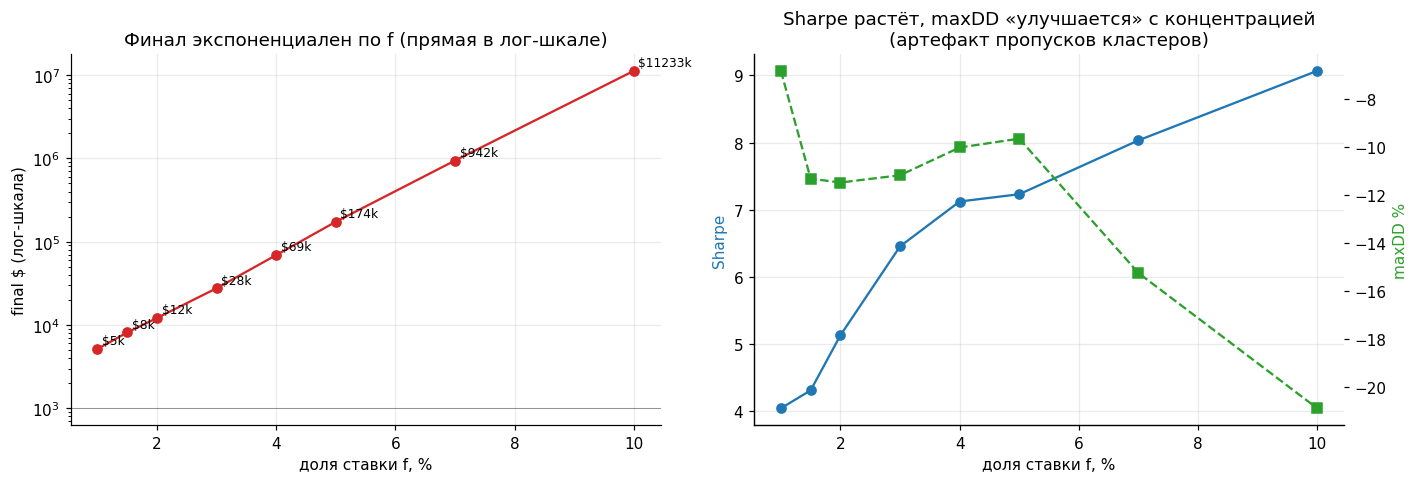

In [4]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].semilogy(S.f*100,S.final,'o-',color='#d62728')
ax[0].axhline(START,color='k',lw=.6,alpha=.4)
ax[0].set_xlabel('доля ставки f, %'); ax[0].set_ylabel('final $ (лог-шкала)')
ax[0].set_title('Финал экспоненциален по f (прямая в лог-шкале)')
for _,r in S.iterrows(): ax[0].annotate(f"${r.final/1000:.0f}k",(r.f*100,r.final),fontsize=8,xytext=(3,3),textcoords='offset points')
ax[1].plot(S.f*100,S.Sharpe,'o-',color='#1f77b4',label='Sharpe (всего счёта)')
ax[1].set_xlabel('доля ставки f, %'); ax[1].set_ylabel('Sharpe',color='#1f77b4')
ax2=ax[1].twinx(); ax2.plot(S.f*100,S.maxDD*100,'s--',color='#2ca02c',label='maxDD')
ax2.set_ylabel('maxDD %',color='#2ca02c'); ax2.grid(False)
ax[1].set_title('Sharpe растёт, maxDD «улучшается» с концентрацией\n(артефакт пропусков кластеров)')
show('comb_06_fsweep')

## Артефакт №2 — рост Sharpe и «улучшение» maxDD с концентрацией = пропуск коррелированных кластеров

При крупной ставке открыто меньше слотов (5% → max ~18 позиций против ~45 при 2%) → больше сигналов
**пропускается**. Пропуски случаются именно в **кластерах** (когда десятки сигналов летят одновременно —
это риск-офф, бьющий все альты разом). Пропуская кластерную экспозицию, агрессивный режим in-sample
показывает **меньше волатильности и меньше DD** — отсюда «агрессивный безопаснее» (что абсурдно).

nb03 уже показал: под **реальной** ёмкостью (ликвидность по символу+времени) этот вывод **переворачивается** —
крупная ставка бьётся о ликвидность раньше, и агрессивный становится ХУЖЕ. Проверим это на faithful-стриме.

## 3. Реалистичный прогон: ёмкость + market-impact слиппедж (модель nb02)

Та же механика, что nb02: на сделку нельзя поставить больше `10% · ликвидность · 30мин`; слиппедж
`= спред 10bp + 0.10·(ордер/ликвидность)`. **Важная оговорка:** в faithful-кэше нет символа монеты,
поэтому ликвидность на сделку **семплирую** из эмпирического распределения (`comb_trades.parquet`, по стриму).
Это ловит главный эффект (крупный ордер не влезает в тонкую монету), но **НЕ** воспроизводит корреляцию
«кластерный день = много тонких монет разом» — т.е. это всё ещё слегка ОПТИМИСТИЧНО. Точное число — в «next».

In [5]:
rng=np.random.default_rng(0)
ct=pd.read_parquet('_out/comb_trades.parquet')
liq_pool={s:ct[ct.stream==s].liq.values for s in ['pump','dump']}
both['liq']=both.stream.map(lambda s: rng.choice(liq_pool[s]))
print('ликвидность (семпл), медиана $/мин — pump ${:,.0f} / dump ${:,.0f}'.format(
    np.median(liq_pool['pump']),np.median(liq_pool['dump'])))

FILL_MIN=30; PART_CAP=0.10; SPREAD=0.0010; IMPACT=0.10
def realbook(df,start,f,reserve,MAX):
    en=df.entry.values.astype('datetime64[ns]'); ex=df.exit_ts.values.astype('datetime64[ns]')
    bpnl=df.pnl.values; liq=df.liq.values; cap_no=PART_CAP*liq*FILL_MIN
    cash=start;dep=0.;openh=[];eq_t=[];eq_v=[];taken=0;capped=0;slip=0.
    for i in range(len(bpnl)):
        while openh and openh[0][0]<=en[i]:
            _,no,pn=heapq.heappop(openh);cash+=no*(1+pn);dep-=no;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
        eq=cash+dep; desired=f*eq; no=min(desired,cap_no[i])
        if no<desired-1e-9: capped+=1
        if dep+no<=(1-reserve)*eq and len(openh)<MAX and cash>=no and no>1:
            part=no/(liq[i]*FILL_MIN); sl=SPREAD+IMPACT*part; slip+=no*sl
            cash-=no;dep+=no;heapq.heappush(openh,(ex[i],no,bpnl[i]-sl));taken+=1
    for _,no,pn in sorted(openh):cash+=no*(1+pn);dep-=no;eq_t.append(pd.Timestamp(_));eq_v.append(cash+dep)
    s=pd.Series(eq_v,index=pd.to_datetime(eq_t)).sort_index();s=s[~s.index.duplicated(keep='last')].resample('1D').last().ffill()
    r=s.pct_change().dropna();sp=(s.index[-1]-s.index[0]).days/365.25
    sh=r.mean()/r.std()*np.sqrt(365) if r.std()>0 else np.nan
    dd=(s.values/np.maximum.accumulate(s.values)-1).min()
    return dict(final=s.iloc[-1],cagr=(s.iloc[-1]/start)**(1/sp)-1,sharpe=sh,dd=dd,
                taken=taken,capped=capped/max(taken,1),slip=slip,eq=s)

modes=[('🟢 безопасный 2%',0.02,0.10,45),('🟡 средний 3%',0.03,0.10,30),('🔴 агрессивный 5%',0.05,0.10,18)]
print('\n=== ИДЕАЛ (nb05) vs РЕАЛИСТ (ёмкость+слиппедж), старт $1000 ===')
print(f"{'режим':<20}{'идеал final':>13}{'идеал CAGR':>12}  |{'реал final':>12}{'реал CAGR':>11}{'Sharpe':>8}{'maxDD':>8}{'capped':>8}")
real_rows=[]
for nm,f,res,mx in modes:
    fin_i,cg_i,_,_,_=final_only(both,f,res)
    R=realbook(both,1000.,f,res,mx); real_rows.append((nm,R))
    print(f"{nm:<20}${fin_i:>11,.0f}{cg_i*100:>+11.0f}%  |${R['final']:>10,.0f}{R['cagr']*100:>+10.0f}%{R['sharpe']:>8.2f}{R['dd']*100:>7.1f}%{R['capped']*100:>7.0f}%")

ликвидность (семпл), медиана $/мин — pump $3,156 / dump $3,803

=== ИДЕАЛ (nb05) vs РЕАЛИСТ (ёмкость+слиппедж), старт $1000 ===
режим                 идеал final  идеал CAGR  |  реал final  реал CAGR  Sharpe   maxDD  capped


🟢 безопасный 2%     $     12,143       +192%  |$     9,548      +164%    4.70  -11.6%      4%


🟡 средний 3%        $     27,653       +316%  |$    17,709      +244%    5.78  -11.4%      6%


🔴 агрессивный 5%    $    173,529       +817%  |$    58,607      +475%    6.07  -10.1%     15%


=== СТЕНА МАСШТАБИРОВАНИЯ (агрессивный 5%, резерв 10%) по стартовому капиталу ===
       старт     CAGR  Sharpe   maxDD  capped        slip
$     1,000    +475%    6.07  -10.1%     15%  $    12,247
$    10,000    +293%    5.44   -9.6%     41%  $    75,622


$    50,000    +181%    4.84   -8.3%     67%  $   214,041
$   200,000    +107%    4.37   -5.1%     91%  $   508,171


$ 1,000,000     +52%    3.93   -3.9%    117%  $ 1,338,038


[saved] notebooks\pump_dump_combined\_out\comb_06_realistic.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_combined/_out/comb_06_realistic.png')

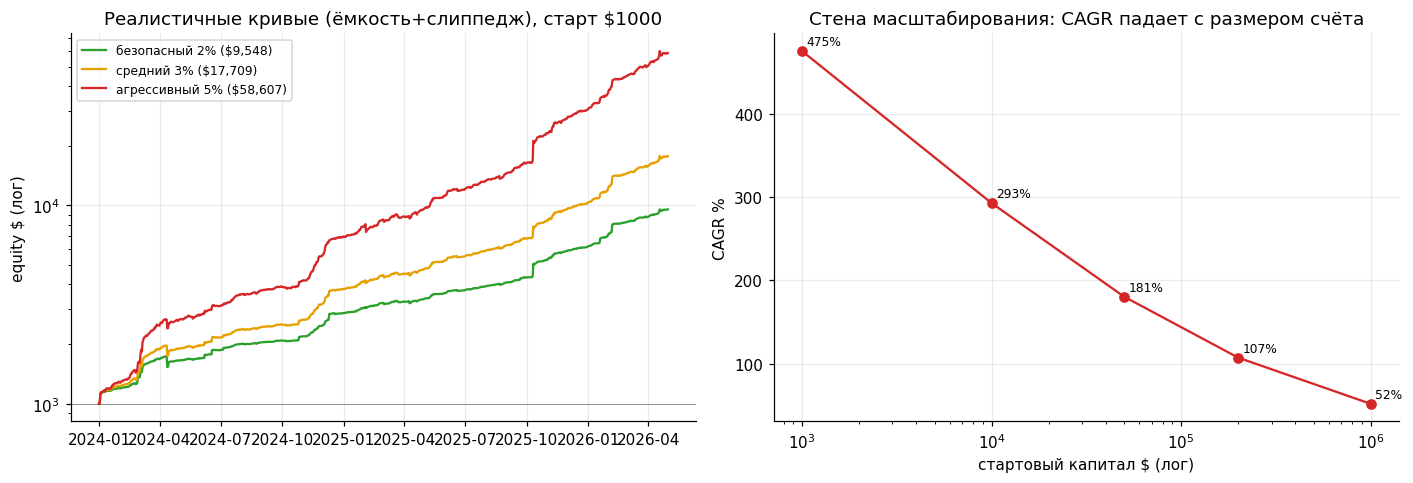

In [6]:
print('=== СТЕНА МАСШТАБИРОВАНИЯ (агрессивный 5%, резерв 10%) по стартовому капиталу ===')
print(f"{'старт':>12}{'CAGR':>9}{'Sharpe':>8}{'maxDD':>8}{'capped':>8}{'slip':>12}")
wall=[]
for start in (1_000,10_000,50_000,200_000,1_000_000):
    R=realbook(both,float(start),0.05,0.10,18); wall.append((start,R))
    print(f"${start:>10,.0f}{R['cagr']*100:>+8.0f}%{R['sharpe']:>8.2f}{R['dd']*100:>7.1f}%{R['capped']*100:>7.0f}%  ${R['slip']:>10,.0f}")

fig,ax=plt.subplots(1,2,figsize=(13,4.5))
col={'🟢 безопасный 2%':'#2ca02c','🟡 средний 3%':'#e6a000','🔴 агрессивный 5%':'#d62728'}
for nm,R in real_rows:
    lab=nm[2:]  # без emoji-кружка (шрифт графика его не рендерит)
    ax[0].plot(R['eq'].index,R['eq'].values,lw=1.5,color=col[nm],label=f"{lab} (${R['final']:,.0f})")
ax[0].axhline(1000,color='k',lw=.6,alpha=.4); ax[0].set_yscale('log')
ax[0].set_ylabel('equity $ (лог)'); ax[0].legend(loc='upper left',fontsize=8)
ax[0].set_title('Реалистичные кривые (ёмкость+слиппедж), старт $1000')
st=[w[0] for w in wall]; cg=[w[1]['cagr']*100 for w in wall]
ax[1].semilogx(st,cg,'o-',color='#d62728')
for s,c in zip(st,cg): ax[1].annotate(f"{c:.0f}%",(s,c),fontsize=8,xytext=(3,4),textcoords='offset points')
ax[1].set_xlabel('стартовый капитал $ (лог)'); ax[1].set_ylabel('CAGR %')
ax[1].set_title('Стена масштабирования: CAGR падает с размером счёта')
show('comb_06_realistic')

## ВЕРДИКТ (nb06)

**Движок nb05 реализован корректно** — капитал сохраняется, ошибки учёта нет. Но **+817% / Sharpe 7.2 — это
не реалистичная доходность**, а два in-sample артефакта:

1. **Компаундинг экспоненциален по доле ставки.** `final ≈ exp(k·f)` — поэтому 2%→5% превращает $12k в $174k.
   Это арифметически верно, но предполагает, что edge **бесконечно масштабируем**: счёт $1k→$174k к концу торгует
   позициями 5%·$174k ≈ $8.7k в монетах с ликвидностью ~$3k/мин. Это ровно стена ёмкости nb02 — задняя половина
   агрессивной кривой физически неисполнима.
2. **Sharpe/maxDD «улучшаются» с концентрацией** не потому, что агрессивный безопаснее, а потому, что он
   **пропускает коррелированные кластеры** (меньше слотов). Это пропадает/переворачивается под реальной ёмкостью.

**Реалистичные числа (ёмкость+слиппедж, старт $1000):** агрессивный +817%→**+475% CAGR**, средний +316%→+244%,
безопасный +192%→+164%. На малом счёте ёмкость жмёт слабо (счёт остаётся мал), поэтому числа всё ещё высокие —
**но это потолок in-sample, не прогноз.** Стена масштабирования крутая: агрессивный +475% ($1k) → +52% ($1M).

**Честный ответ «какая реальная доходность»:** это **нишевая стратегия для малого капитала**; релевантна
DCA-форма из nb02 (~$9k из $2.8k взносов), а не 817%. Для серьёзного капитала CAGR схлопывается.

**Оговорка / next.** Ликвидность здесь **семплирована** (нет символа в кэше) → корреляция «кластер = тонкие
монеты» не воспроизведена, поэтому реалист всё ещё слегка оптимистичен и ранжирование режимов пока НЕ
перевернулось (в nb03 на реальной liq оно переворачивается — агрессивный становится хуже безопасного).
**Следующий шаг:** пересобрать faithful combined из сырья с символом+ликвидностью на сделку, чтобы получить
точные per-mode числа под реальной ёмкостью (и подтвердить разворот ранжирования).